Dependencies

In [76]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import PercentFormatter

Data

In [77]:
# inputs
tickers = ['VWRL.L', 'IBC1.MU', 'IGLN.L', 'BTC-USD']
start_date = "2023-01-01"
end_date = "2026-01-01"
interval = "1d"

# api call
raw_price_data = yf.download(tickers, start=start_date, end=end_date, interval=interval)['Close']
print(raw_price_data.head())
print(raw_price_data.tail())


[*********************100%***********************]  4 of 4 completed

Ticker           BTC-USD    IBC1.MU     IGLN.L     VWRL.L
Date                                                     
2023-01-01  16625.080078        NaN        NaN        NaN
2023-01-02  16688.470703  95.330002        NaN        NaN
2023-01-03  16679.857422  96.330002  35.637501  78.198318
2023-01-04  16863.238281  95.879997  36.197498  78.826332
2023-01-05  16836.736328  96.040001  35.665001  78.901878
Ticker           BTC-USD     IBC1.MU     IGLN.L      VWRL.L
Date                                                       
2025-12-27  87802.156250         NaN        NaN         NaN
2025-12-28  87835.835938         NaN        NaN         NaN
2025-12-29  87138.140625  100.879997  84.247498  122.422371
2025-12-30  88430.132812  101.000000  84.747498  122.958221
2025-12-31  87508.828125         NaN  83.650002  122.720062


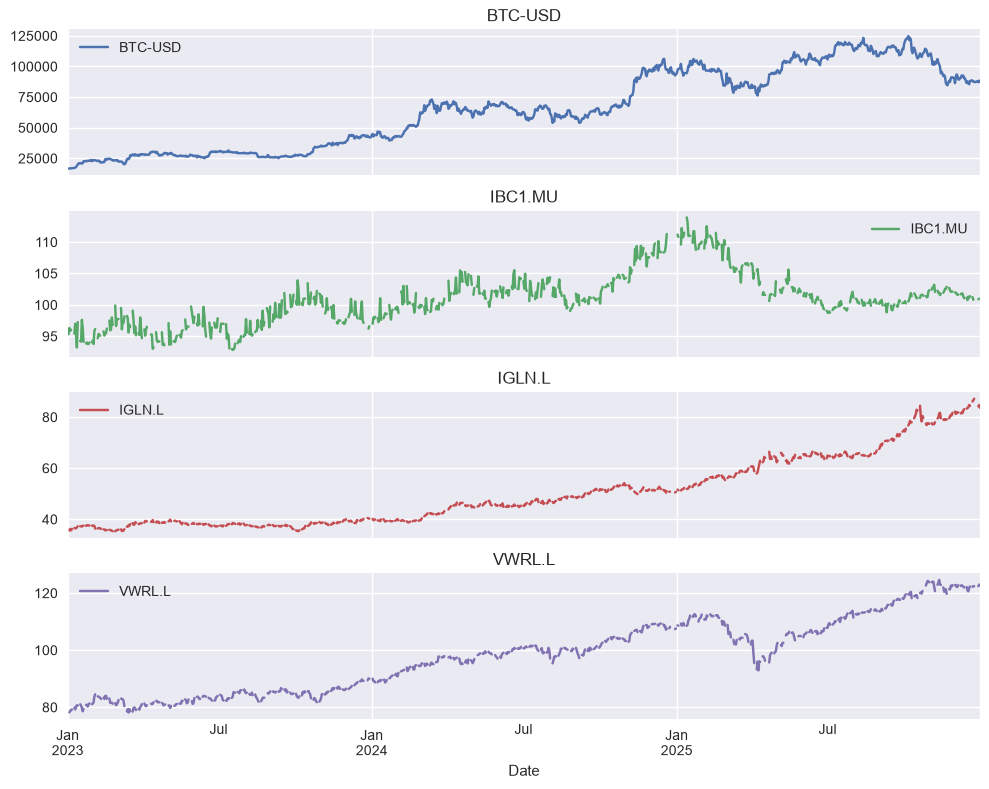

In [78]:
raw_price_data.plot(subplots=True, figsize=(10, 8), title=list(raw_price_data.columns))
plt.tight_layout()
plt.show()

EDA

In [79]:
raw_price_data.shape

(1096, 4)

In [80]:
raw_price_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1096 entries, 2023-01-01 to 2025-12-31
Freq: D
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  1096 non-null   float64
 1   IBC1.MU  755 non-null    float64
 2   IGLN.L   758 non-null    float64
 3   VWRL.L   757 non-null    float64
dtypes: float64(4)
memory usage: 42.8 KB


In [81]:
print(raw_price_data.isna().sum())
print(raw_price_data.isna().sum() / len(raw_price_data) * 100)  

Ticker
BTC-USD      0
IBC1.MU    341
IGLN.L     338
VWRL.L     339
dtype: int64
Ticker
BTC-USD     0.000000
IBC1.MU    31.113139
IGLN.L     30.839416
VWRL.L     30.930657
dtype: float64


In [82]:
returns = raw_price_data.pct_change().dropna()
returns.head()

Ticker,BTC-USD,IBC1.MU,IGLN.L,VWRL.L
Date,,,,
2023-01-04,0.010994,-0.004671,0.015714,0.008031
2023-01-05,-0.001572,0.001669,-0.014711,0.000958
2023-01-10,0.014523,0.016454,-0.000137,-0.007805
2023-01-11,0.028006,-0.016393,-0.001916,0.012634
2023-01-12,0.052116,-0.022851,0.010560,0.005826


In [83]:
returns.describe()

Ticker,BTC-USD,IBC1.MU,IGLN.L,VWRL.L
count,582.000000,582.000000,582.000000,582.000000
mean,0.001311,-0.000118,0.001265,0.000395
std,0.026096,0.011956,0.009328,0.007654
min,-0.083434,-0.035427,-0.051091,-0.041362
25%,-0.013708,-0.005313,-0.003899,-0.003187
50%,-0.000718,0.000000,0.001510,0.000648
75%,0.015123,0.004691,0.006669,0.004244
max,0.121443,0.043338,0.029582,0.034246


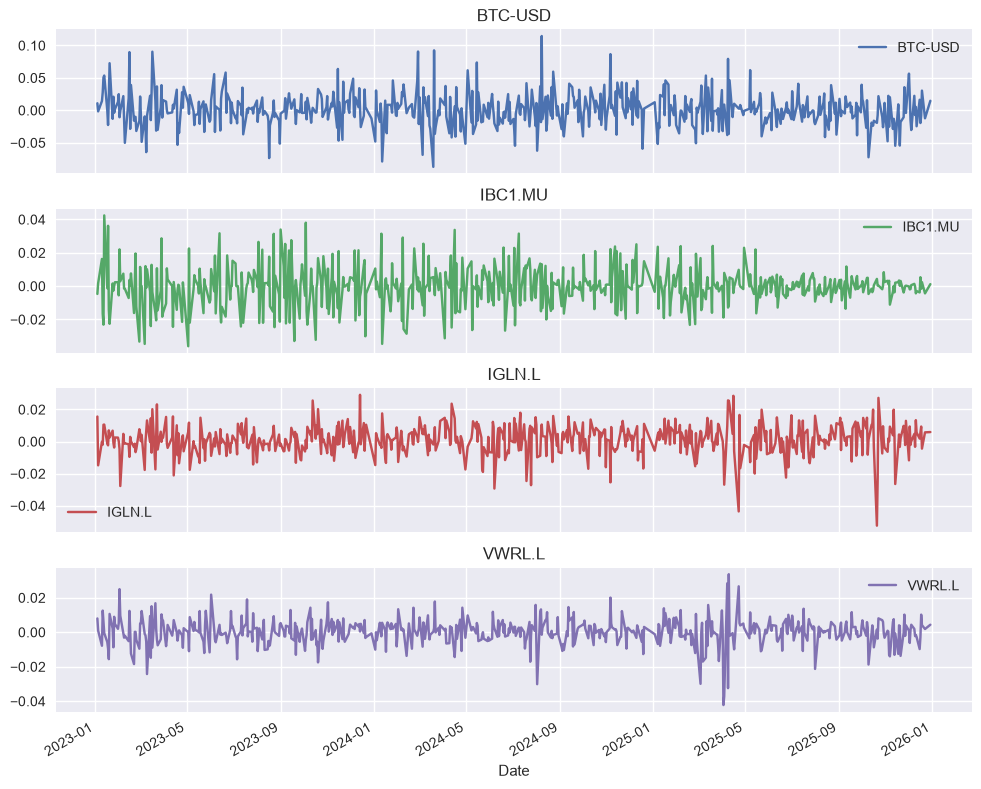

In [87]:
log_returns = np.log(raw_price_data / raw_price_data.shift(1)).dropna()
log_returns.plot(subplots=True, figsize=(10, 8), title=list(log_returns.columns))
plt.tight_layout()
plt.show()

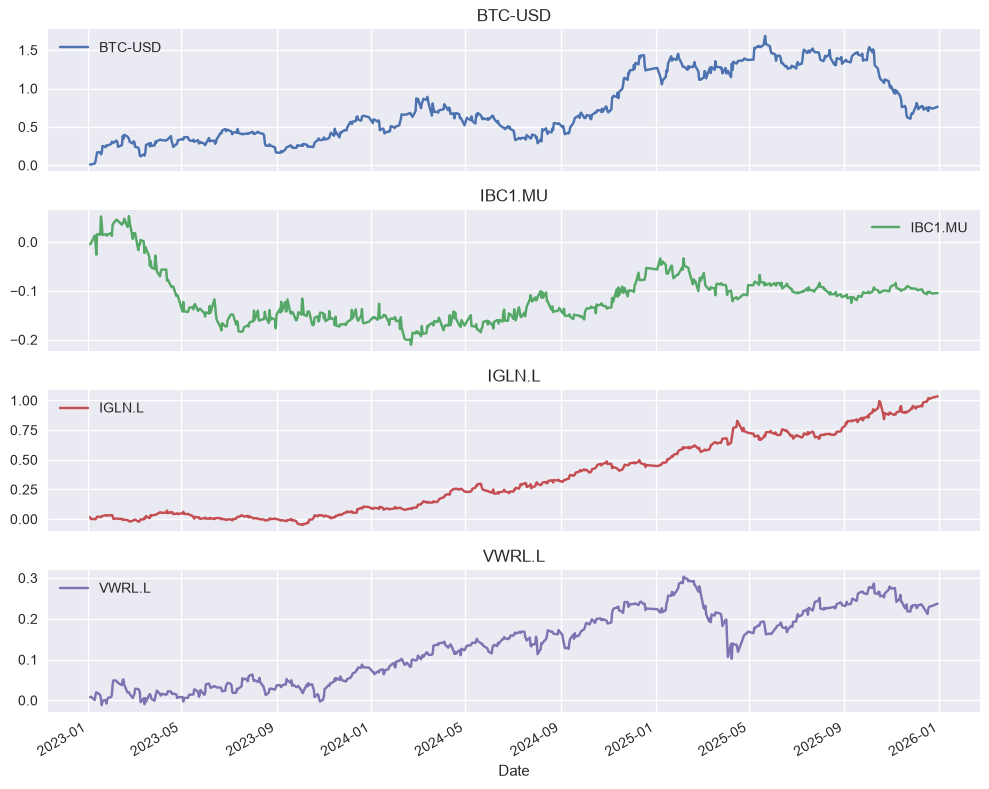

In [88]:
cumulative_returns = np.exp(log_returns.cumsum()) - 1
cumulative_returns.plot(subplots=True, figsize=(10, 8), title=list(cumulative_returns.columns))
plt.tight_layout()
plt.show()

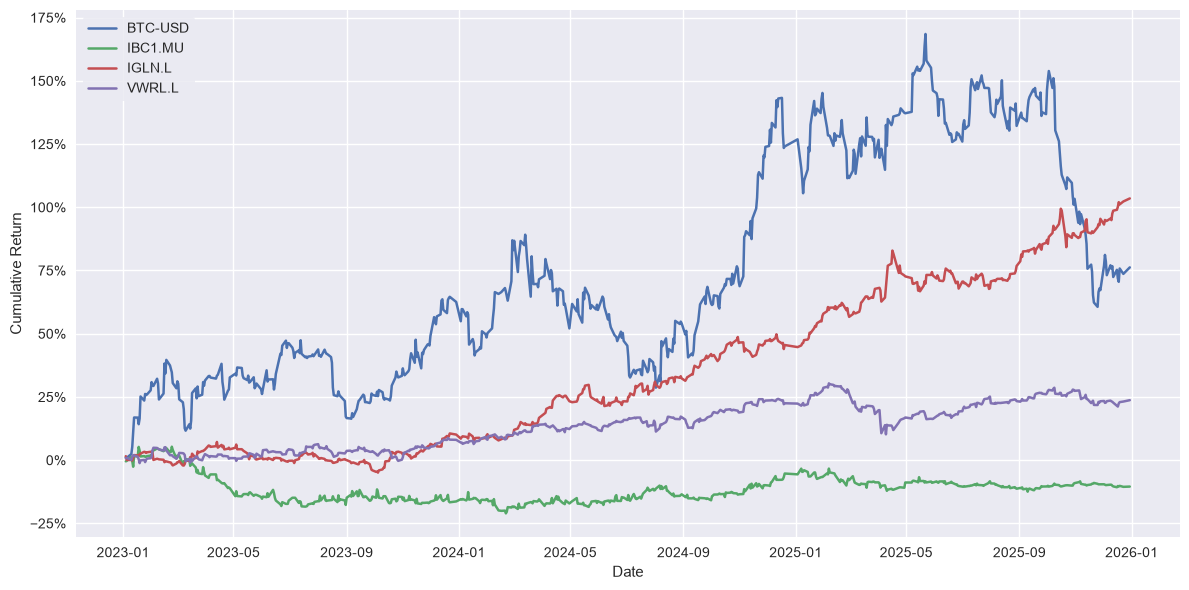

In [89]:
fig, ax = plt.subplots(figsize=(12, 6))

for col in cumulative_returns.columns:
    ax.plot(cumulative_returns.index, cumulative_returns[col].values, linewidth=1.8, label=col)

ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

# ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(loc="upper left", frameon=True)
leg.get_frame().set_alpha(0.85)
leg.get_frame().set_linewidth(0.0)

plt.tight_layout()
plt.show()

In [91]:
log_returns.corr()

Ticker,BTC-USD,IBC1.MU,IGLN.L,VWRL.L
Ticker,,,,
BTC-USD,1.000000,0.015475,0.063540,0.114257
IBC1.MU,0.015475,1.000000,-0.070397,0.034228
IGLN.L,0.063540,-0.070397,1.000000,-0.073662
VWRL.L,0.114257,0.034228,-0.073662,1.000000


In [92]:
log_returns.std()

Ticker
BTC-USD    0.025928
IBC1.MU    0.011951
IGLN.L     0.009344
VWRL.L     0.007668
dtype: float64

In [93]:
log_returns.mean()

Ticker
BTC-USD    0.000974
IBC1.MU   -0.000190
IGLN.L     0.001221
VWRL.L     0.000366
dtype: float64

In [95]:
sharpe = log_returns.mean() / log_returns.std() * np.sqrt(252)
sharpe

Ticker
BTC-USD    0.596103
IBC1.MU   -0.251913
IGLN.L     2.073918
VWRL.L     0.757045
dtype: float64

[*********************100%***********************]  1 of 1 completed


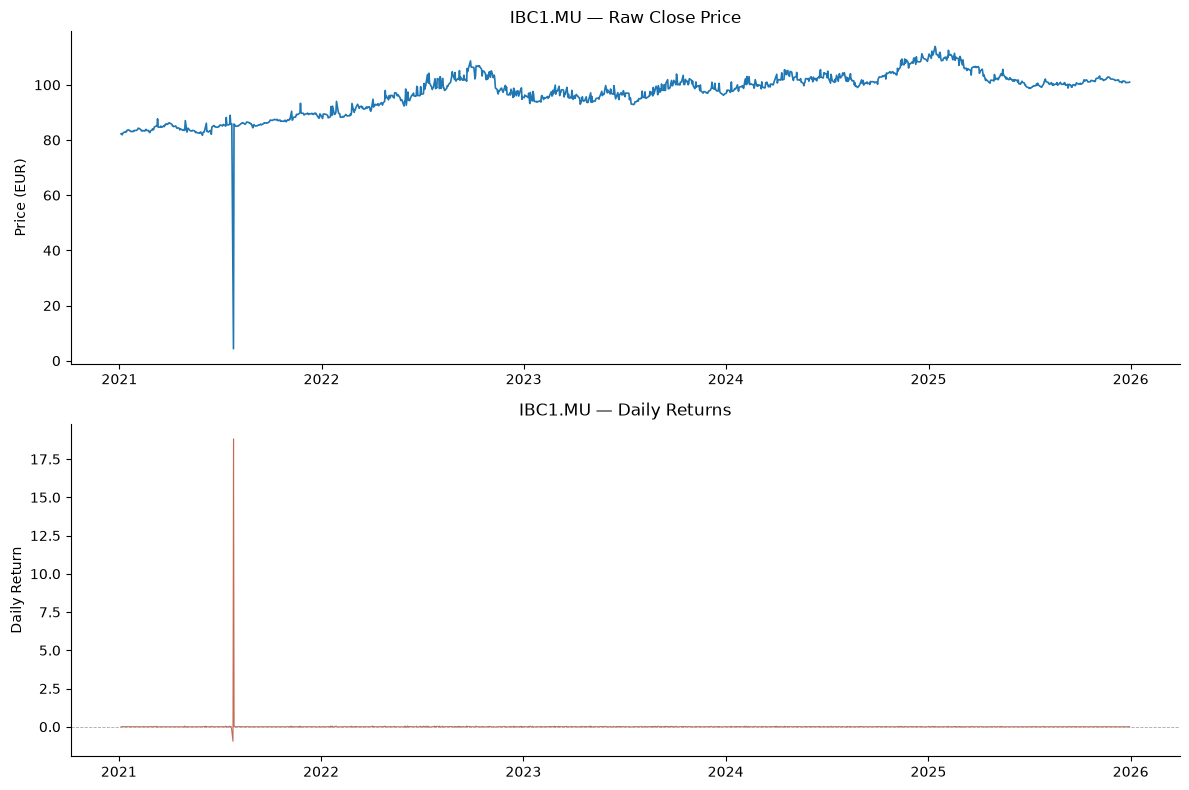

Non-null rows: Ticker
IBC1.MU    1266
dtype: int64 / 1266


TypeError: unsupported format string passed to Series.__format__

In [2]:
import matplotlib.pyplot as plt

raw_ibc1 = yf.download("IBC1.MU", start="2021-01-01", end="2026-01-01", auto_adjust=True)["Close"]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Price series
axes[0].plot(raw_ibc1.index, raw_ibc1.values, linewidth=1.2)
axes[0].set_title("IBC1.MU — Raw Close Price")
axes[0].set_ylabel("Price (EUR)")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Daily returns
ret_ibc1 = raw_ibc1.pct_change().dropna()
axes[1].plot(ret_ibc1.index, ret_ibc1.values, linewidth=0.8, color="#c46a52")
axes[1].axhline(0, color="#a0a8b0", linewidth=0.6, linestyle="--")
axes[1].set_title("IBC1.MU — Daily Returns")
axes[1].set_ylabel("Daily Return")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Non-null rows: {raw_ibc1.notna().sum()} / {len(raw_ibc1)}")
print(f"Max daily return: {ret_ibc1.max():.2%}")
print(f"Min daily return: {ret_ibc1.min():.2%}")